# Topic Modeling 

## Preprocessing
* Lowercasing
* Tokenization
* Punctuation removal
* Stop word removal
* Lemmatization
--> Save prerpocessed data as pickle
  
## Model training & evaluation
* run TF-IDF to downweigh common words
* run NMF for topic modeling
* evaluate model quality across different k
* identify optimal number of topics using coherence, diversity and reconstruction error
--> Plot metrics

## Evaluation & Visualization of results in clusters
* use PCA to visualize topic clusters
--> Present topic clusters and top words for optimal k

## Install & Import

In [13]:
import kagglehub

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## Loading the Data

In [ ]:
# Download latest version of the data set
path = kagglehub.dataset_download("sumitm004/reddit-raskscience-flair-dataset")
print("Import finished.")

100%|██████████| 45.2M/45.2M [00:03<00:00, 14.8MB/s]

Extracting files...


In [3]:
# Load data (relevant columns only)
df = pd.read_csv(f"{path}/flair_data.csv", usecols=[0, 4, 5, 6])
df.head()

,id,question,link_flair_css_class,link_flair_text
0,421zyl,How is time defined at the big bang?,physics,Physics
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.


In [4]:
# Inspect data
print(df.shape)
print()
print(df.columns.tolist())
print()
print(df.info())
print()
df.head()

(612668, 4)

['id', 'question', 'link_flair_css_class', 'link_flair_text']

<class 'pandas.DataFrame'>
RangeIndex: 612668 entries, 0 to 612667
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    612668 non-null  str  
 1   question              612668 non-null  str  
 2   link_flair_css_class  612668 non-null  str  
 3   link_flair_text       612668 non-null  str  
dtypes: str(4)
memory usage: 18.7 MB
None



,id,question,link_flair_css_class,link_flair_text
0,421zyl,How is time defined at the big bang?,physics,Physics
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.


## Data Cleaning & Preprocessing

### Handling Missing Values

In [5]:
# List the number of missing values per column
df.isnull().sum()

id                      0
question                0
link_flair_css_class    0
link_flair_text         0
dtype: int64

No missing values.


### Handling Duplicates

In [6]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

No duplicates.

## Exploratory Plots & Summary Statistics
The data set contains 612,668 data points corresponding to as many posts in r/askscience. In the following the distribution of papers across time and categories will be examined.

### Colors, Styles & Presets

In [7]:
# Plot style
sns.set_theme(style='whitegrid', context='paper')

### Distribution across Categories

In [38]:
len(df['link_flair_css_class'].unique().tolist())

16

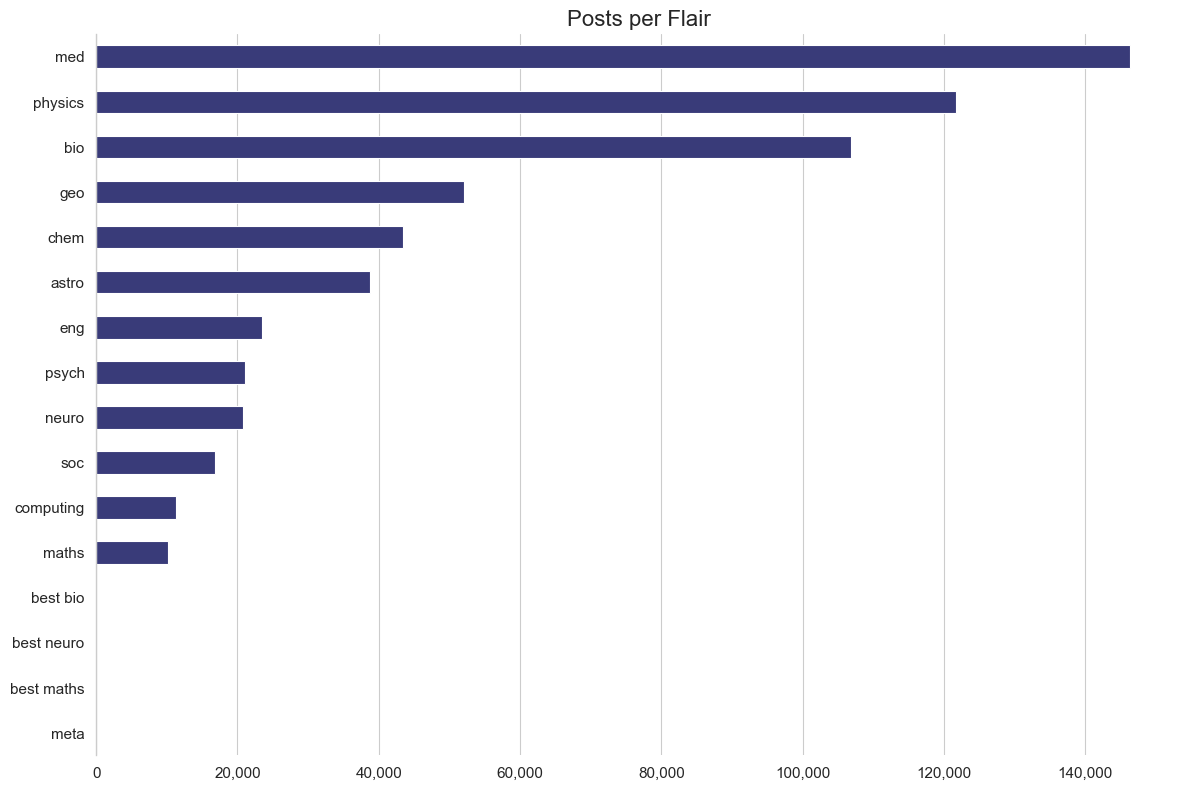

In [39]:
counts = df["link_flair_css_class"].value_counts()
counts = counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12,8))
counts.plot(kind="barh", ax=ax, colormap='tab20b')

plt.xlabel("")
plt.ylabel("")
plt.title("Posts per Flair", fontsize=16)
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Hide horizontal gridlines
plt.grid(axis="y", visible=False)

plt.tight_layout()

plt.show()

In [11]:
counts

link_flair_css_class
meta               1
best maths         1
best neuro         1
best bio           2
maths          10162
computing      11277
soc            16804
neuro          20797
psych          21047
eng            23502
astro          38772
chem           43436
geo            52007
bio           106808
physics       121776
med           146275
Name: count, dtype: int64

## Data Preprocessing for NLP

### Lowercasing, Tokenization, Punctuation Removal, Stop Word Removal & Lemmatization
For NLP only a subset of the data is used. All papers from 2022 onwards are considered relevant for recent trends and current topics. Older papers are not included since they carry little value regarden recent and future developments and blow up processing times.

## Lowercasing

In [30]:
df["text"] = df["question"].str.lower()

## Punctuation & Reddit Artifact Removal

In [31]:
# Remove URLs
df["text"] = df["text"].str.replace(r"http\S+|www\S+", "", regex=True)
# Remove user and subreddit mentions
df["text"] = df["text"].str.replace(r"/u/\w+|/r/\w+", "", regex=True)
# Remove special characters
df["text"] = df["text"].str.replace(r"[^\w\s]", "", regex=True)

## Tokenization

In [32]:
df["tokens"] = df["text"].str.split()
df

,id,question,link_flair_css_class,link_flair_text,text,tokens
0,421zyl,How is time defined at the big bang?,physics,Physics,how is time defined at the big bang,"[how, is, time, defined, at, the, big, bang]"
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo best scientific explanation atmospherical ...,"[ufo, best, scientific, explanation, atmospher..."
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,its a commonly known fact that metals oxidize ...,"[its, a, commonly, known, fact, that, metals, ..."
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy,china builds large telescope but i have a ques...,"[china, builds, large, telescope, but, i, have..."
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientists is there any current research in...,"[geoscientists, is, there, any, current, resea..."
...,...,...,...,...,...,...
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentists ive got a question for you why do den...,"[dentists, ive, got, a, question, for, you, wh..."
612664,ry6nvu,Why did we evolve to have consciousness?,bio,Biology,why did we evolve to have consciousness,"[why, did, we, evolve, to, have, consciousness]"
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,why dont the oceans get saltier over time or d...,"[why, dont, the, oceans, get, saltier, over, t..."
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,would tracing paper be classed as translucent ...,"[would, tracing, paper, be, classed, as, trans..."


## Stop Word Removal

In [33]:
import spacy

nlp = spacy.load("en_core_web_sm")

stop_words = nlp.Defaults.stop_words

df["tokens"] = df["tokens"].apply(
    lambda tokens: [t for t in tokens if isinstance(t, str) and t not in stop_words]
)

## Lemmatization

In [34]:
def lemmatize_text(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc]

df["tokens"] = df["text"].apply(lemmatize_text)
df

,id,question,link_flair_css_class,link_flair_text,text,tokens
0,421zyl,How is time defined at the big bang?,physics,Physics,how is time defined at the big bang,"[how, be, time, define, at, the, big, bang]"
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo best scientific explanation atmospherical ...,"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,its a commonly known fact that metals oxidize ...,"[its, a, commonly, know, fact, that, metal, ox..."
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy,china builds large telescope but i have a ques...,"[china, build, large, telescope, but, I, have,..."
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientists is there any current research in...,"[geoscientist, be, there, any, current, resear..."
...,...,...,...,...,...,...
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentists ive got a question for you why do den...,"[dentist, I, ve, get, a, question, for, you, w..."
612664,ry6nvu,Why did we evolve to have consciousness?,bio,Biology,why did we evolve to have consciousness,"[why, do, we, evolve, to, have, consciousness]"
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,why dont the oceans get saltier over time or d...,"[why, do, not, the, ocean, get, salty, over, t..."
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,would tracing paper be classed as translucent ...,"[would, trace, paper, be, class, as, transluce..."


### Optional: Convert back to Strings (required for LDA)

In [35]:
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))
df

,id,question,link_flair_css_class,link_flair_text,text,tokens,clean_text
0,421zyl,How is time defined at the big bang?,physics,Physics,how is time defined at the big bang,"[how, be, time, define, at, the, big, bang]",how be time define at the big bang
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo best scientific explanation atmospherical ...,"[ufo, good, scientific, explanation, atmospher...",ufo good scientific explanation atmospherical ...
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,its a commonly known fact that metals oxidize ...,"[its, a, commonly, know, fact, that, metal, ox...",its a commonly know fact that metal oxidize bu...
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy,china builds large telescope but i have a ques...,"[china, build, large, telescope, but, I, have,...",china build large telescope but I have a question
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientists is there any current research in...,"[geoscientist, be, there, any, current, resear...",geoscientist be there any current research int...
...,...,...,...,...,...,...,...
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentists ive got a question for you why do den...,"[dentist, I, ve, get, a, question, for, you, w...",dentist I ve get a question for you why do den...
612664,ry6nvu,Why did we evolve to have consciousness?,bio,Biology,why did we evolve to have consciousness,"[why, do, we, evolve, to, have, consciousness]",why do we evolve to have consciousness
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,why dont the oceans get saltier over time or d...,"[why, do, not, the, ocean, get, salty, over, t...",why do not the ocean get salty over time or do...
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,would tracing paper be classed as translucent ...,"[would, trace, paper, be, class, as, transluce...",would trace paper be class as translucent or t...


In [41]:
# Save lemmatized df to pickle file
df.to_pickle("data/preprocessed_data.pkl")

In [44]:
df = pd.read_pickle("data/preprocessed_data.pkl")
df

,id,question,link_flair_css_class,link_flair_text,text,tokens,clean_text
0,421zyl,How is time defined at the big bang?,physics,Physics,how is time defined at the big bang,"[how, be, time, define, at, the, big, bang]",how be time define at the big bang
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo best scientific explanation atmospherical ...,"[ufo, good, scientific, explanation, atmospher...",ufo good scientific explanation atmospherical ...
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,its a commonly known fact that metals oxidize ...,"[its, a, commonly, know, fact, that, metal, ox...",its a commonly know fact that metal oxidize bu...
3,540ohz,"China builds large telescope, but i have a que...",astro,Astronomy,china builds large telescope but i have a ques...,"[china, build, large, telescope, but, I, have,...",china build large telescope but I have a question
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientists is there any current research in...,"[geoscientist, be, there, any, current, resear...",geoscientist be there any current research int...
...,...,...,...,...,...,...,...
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentists ive got a question for you why do den...,"[dentist, I, ve, get, a, question, for, you, w...",dentist I ve get a question for you why do den...
612664,ry6nvu,Why did we evolve to have consciousness?,bio,Biology,why did we evolve to have consciousness,"[why, do, we, evolve, to, have, consciousness]",why do we evolve to have consciousness
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,why dont the oceans get saltier over time or d...,"[why, do, not, the, ocean, get, salty, over, t...",why do not the ocean get salty over time or do...
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,would tracing paper be classed as translucent ...,"[would, trace, paper, be, class, as, transluce...",would trace paper be class as translucent or t...


## Vectorization

# NMF with TIDF and Evaluation Metrics

### Load Preprocessed Data & Prepare for NMF

In [27]:
# Load preprocessed data
df = pd.read_pickle("arxiv_short.pkl")
print(df.shape)
df.head()

(960743, 19)


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed,year,categories_list,subject,text,tokens
2439584,2510.07758,Qiaozhe Zhang,"Qiaozhe Zhang, Jun Sun, Ruijie Zhang, Yingzhua...",R\'enyi Sharpness: A Novel Sharpness that Stro...,None,None,None,None,cs.LG,http://creativecommons.org/licenses/by/4.0/,Sharpness (of the loss minima) is a common mea...,"[{'version': 'v1', 'created': 'Thu, 09 Oct 202...",2025-10-10,"[[Zhang, Qiaozhe, ], [Sun, Jun, ], [Zhang, Rui...",2025,[cs.LG],[cs],R\'enyi Sharpness: A Novel Sharpness that Stro...,"[sharpness, novel, sharpness, strongly, correl..."
2439455,2510.07629,Zhangdie Yuan,"Zhangdie Yuan, Han-Chin Shing, Mitch Strong, C...",Toward Reliable Clinical Coding with Language ...,None,None,None,None,cs.CL,http://arxiv.org/licenses/nonexclusive-distrib...,Accurate clinical coding is essential for heal...,"[{'version': 'v1', 'created': 'Wed, 08 Oct 202...",2025-10-10,"[[Yuan, Zhangdie, ], [Shing, Han-Chin, ], [Str...",2025,[cs.CL],[cs],Toward Reliable Clinical Coding with Language ...,"[reliable, clinical, coding, language, models,..."
2439470,2510.07644,Shuoqi Sun,"Shuoqi Sun, Danula Hettiachchi, Damiano Spina",ISMIE: A Framework to Characterize Information...,This paper has been accepted to SIGIR-AP 2025,None,10.1145/3767695.3769509,None,cs.IR,http://creativecommons.org/licenses/by-nc-sa/4.0/,The modern information environment (MIE) is in...,"[{'version': 'v1', 'created': 'Thu, 09 Oct 202...",2025-10-10,"[[Sun, Shuoqi, ], [Hettiachchi, Danula, ], [Sp...",2025,[cs.IR],[cs],ISMIE: A Framework to Characterize Information...,"[ismie, framework, characterize, information, ..."
2439469,2510.07643,Valery Asiryan,Valery Asiryan,On the Irreducibility of the Cuboid Polynomial...,None,None,None,None,math.GM,http://creativecommons.org/licenses/by/4.0/,In this paper we consider the even monic degre...,"[{'version': 'v1', 'created': 'Thu, 09 Oct 202...",2025-10-10,"[[Asiryan, Valery, ]]",2025,[math.GM],[math],On the Irreducibility of the Cuboid Polynomial...,"[irreducibility, cuboid, polynomial, paper, co..."
2439468,2510.07642,Anthony Rios,"{\DJ}or{\dj}e Klisura, Joseph Khoury, Ashish K...",Role-Conditioned Refusals: Evaluating Access C...,8 pages + Appendix,None,None,None,cs.CL,http://creativecommons.org/licenses/by/4.0/,Access control is a cornerstone of secure comp...,"[{'version': 'v1', 'created': 'Thu, 09 Oct 202...",2025-10-10,"[[Klisura, Đorđe, ], [Khoury, Joseph, ], [Kund...",2025,[cs.CL],[cs],Role-Conditioned Refusals: Evaluating Access C...,"[role, condition, refusal, evaluate, access, c..."


In [28]:
# Join tokens into text for TF–IDF
documents = df['tokens'].apply(lambda x: ' '.join(x))

# TF–IDF vectorization
vectorizer = TfidfVectorizer(max_features=100000)
X = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

### Define Helper Functions for Evaluation Metrics & Visualization

In [29]:
# Helper functions
def get_top_words(model, feature_names, n_top=15):
    """Return top words for each topic as list of lists."""
    topics = []
    for comp in model.components_:
        top_idx = np.argsort(comp)[::-1][:n_top]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def topic_diversity(topics, topk=10):
    """Compute topic diversity: fraction of unique words among topk words."""
    top_words = [word for topic in topics for word in topic[:topk]]
    return len(set(top_words)) / len(top_words)

### NMF Loop for different values of *k*

In [30]:
# Setup
topic_nums = range(2, 61, 1)
errors, coherences, diversities = [], [], []

tokenized_docs = df['tokens'].tolist()
dictionary = Dictionary(tokenized_docs)

In [31]:
# Main loop for different values of k
for k in topic_nums:
    print(f"Running NMF for k={k}")

    # Fit NMF model
    nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
    W = nmf.fit_transform(X)
    H = nmf.components_
    errors.append(nmf.reconstruction_err_)

    # Get top words per topic
    topics = get_top_words(nmf, feature_names, n_top=15)

    # Assign dominant topic
    df_temp = df.copy()
    df_temp['dominant_topic'] = W.argmax(axis=1)

    # Topic labels for display
    topic_labels = {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-4:-1]]
        topic_labels[topic_idx] = f"Topic {topic_idx}: {', '.join(top_words)}"

    df_temp['topic_label'] = df_temp['dominant_topic'].map(topic_labels)

    # Compute metrics
    # Topic coherence
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherences.append(coherence_model.get_coherence())
    # Topic diversity
    diversities.append(topic_diversity(topics))


Running NMF for k=2
Running NMF for k=3
Running NMF for k=4
Running NMF for k=5
Running NMF for k=6
Running NMF for k=7
Running NMF for k=8
Running NMF for k=9
Running NMF for k=10
Running NMF for k=11
Running NMF for k=12
Running NMF for k=13
Running NMF for k=14
Running NMF for k=15
Running NMF for k=16
Running NMF for k=17
Running NMF for k=18
Running NMF for k=19
Running NMF for k=20
Running NMF for k=21
Running NMF for k=22
Running NMF for k=23
Running NMF for k=24
Running NMF for k=25
Running NMF for k=26
Running NMF for k=27
Running NMF for k=28
Running NMF for k=29
Running NMF for k=30
Running NMF for k=31
Running NMF for k=32
Running NMF for k=33
Running NMF for k=34
Running NMF for k=35
Running NMF for k=36
Running NMF for k=37
Running NMF for k=38
Running NMF for k=39
Running NMF for k=40
Running NMF for k=41
Running NMF for k=42
Running NMF for k=43
Running NMF for k=44
Running NMF for k=45
Running NMF for k=46
Running NMF for k=47
Running NMF for k=48
Running NMF for k=49


### Plot Evaluation Metrics

In [32]:
# Build summary table
summary = pd.DataFrame({
    'k': topic_nums,
    'Coherence': coherences,
    'Diversity': diversities,
    'Reconstruction_Error': errors
})

# Normalize metrics (0–1 scale)
scaler = MinMaxScaler()
summary[['Coherence_norm', 'Diversity_norm', 'Error_norm']] = scaler.fit_transform(
    summary[['Coherence', 'Diversity', 'Reconstruction_Error']]
)

# Calculate weighted composite score
weights = {'Coherence': 0.6, 'Diversity': 0.3, 'Reconstruction_Error': 0.1}
summary['Composite_Score'] = (
    weights['Coherence'] * summary['Coherence_norm'] +
    weights['Diversity'] * summary['Diversity_norm'] +
    weights['Reconstruction_Error'] * summary['Error_norm']
)

# Print table with scores
summary[['k', 'Coherence', 'Diversity', 'Reconstruction_Error', 'Coherence_norm', 'Diversity_norm', 'Error_norm']]

,k,Coherence,Diversity,Reconstruction_Error,Coherence_norm,Diversity_norm,Error_norm
0,2,0.498069,1.000000,967.625158,0.000000,1.000000,1.000000
1,3,0.540698,1.000000,965.797251,0.273758,1.000000,0.953938
2,4,0.559869,0.950000,964.090305,0.396872,0.802013,0.910925
3,5,0.572144,0.940000,962.607405,0.475696,0.762416,0.873557
4,6,0.616250,0.950000,961.299181,0.758937,0.802013,0.840590
5,7,0.595334,0.914286,960.071168,0.624619,0.660594,0.809645
6,8,0.621886,0.925000,958.921684,0.795137,0.703020,0.780679
7,9,0.634616,0.922222,957.920475,0.876880,0.692021,0.755450
8,10,0.639699,0.910000,956.960487,0.909526,0.643624,0.731259
9,11,0.653788,0.900000,956.092652,1.000000,0.604027,0.709390


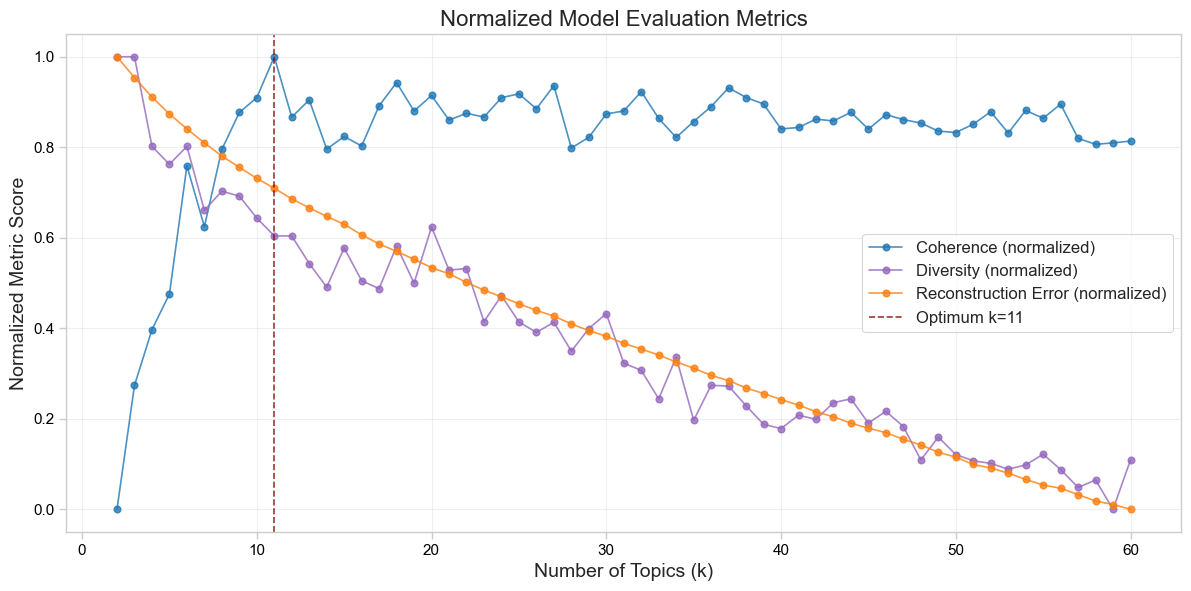

In [33]:
# Plot model evaluation metrics
plt.figure(figsize=(12, 6))

plt.plot(summary['k'], summary['Coherence_norm'], marker='o', color='#1f77b4', label='Coherence (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Diversity_norm'], marker='o', color='#9467bd', label='Diversity (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Error_norm'], marker='o', color='#ff7f0e', label='Reconstruction Error (normalized)', alpha=0.8)

# Highlight best k
plt.axvline(11, color='darkred', linestyle='--', label='Optimum k=11', alpha=0.8)

plt.xlabel("Number of Topics (k)", fontsize=14)
plt.ylabel("Normalized Metric Score", fontsize=14)
plt.title("Normalized Model Evaluation Metrics", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Axes & tick styling
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_color(spine_color)

ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    left=True,
    color=spine_color,
    labelcolor='black',
    labelsize=11
)

plt.tight_layout()
plt.savefig('Visualizations/nmf_all_metrics.png', dpi=300)
plt.show()

## NMF with k=11

In [34]:
# Selected model with k=11
k = 11

nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
W = nmf.fit_transform(X)
H = nmf.components_

# Print top words per topic
num_top_words = 10
for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-num_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]

# Get top words per topic
topics = get_top_words(nmf, feature_names, n_top=15)
pd.DataFrame(topics).to_csv(f"NMF_Topics/topic_words_k{k}.csv", index_label="Topic")

# Assign dominant topic
df_temp = df.copy()
df_temp['dominant_topic'] = W.argmax(axis=1)

In [35]:
# Create topic labels for better plot readability/ interpretability
topic_labels = {
    0: "Deep learning & neural networks",
    1: "Condensed matter & magnetism",
    2: "Numerical optimization & SDEs",
    3: "Quantum computing",
    4: "GNNs & graph algorithms",
    5: "LLMs & NLP",
    6: "Computer vision & image processing",
    7: "Astrophysics – galaxy formation",
    8: "Robotics & human–machine interactions",
    9: "Linear algebra & mathematical theory",
    10: "Black hole & dark matter physics"
}

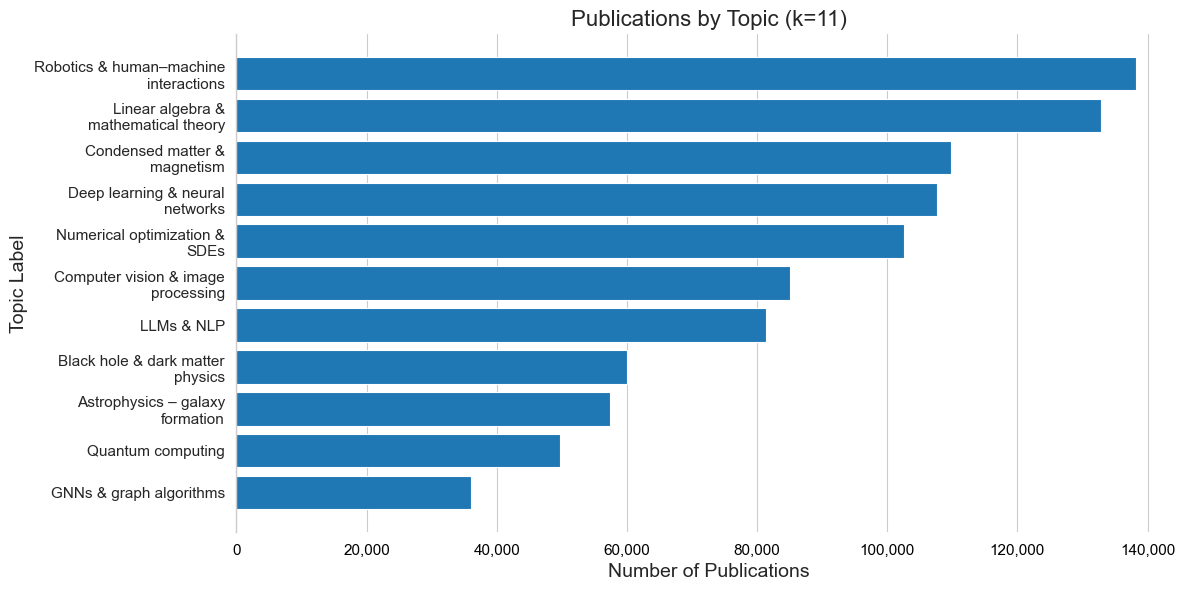

In [43]:
# Visualize distribution of paper across topics
fig, ax = plt.subplots(figsize=(12, 6))

# Count documents per topic and sort ascending for horizontal bar
topic_counts = df_temp['dominant_topic'].value_counts().sort_values(ascending=True)
topics_sorted = topic_counts.index

# Wrap labels and append topic number
wrapped_labels = [
"\n".join(textwrap.wrap(f"{topic_labels[t]}", width=25))
for t in topics_sorted
]

# Horizontal bar plot
ax.barh(
    y=range(len(topics_sorted)),
    width=topic_counts.values,
    color="#1f77b4"
)

# y-Axis labels
ax.set_yticks(range(len(topics_sorted)))
ax.set_yticklabels(wrapped_labels, fontsize=11)

# Labels and title
ax.set_xlabel("Number of Publications", fontsize=14)
ax.set_ylabel("Topic Label", fontsize=14)
ax.set_title(f"Publications by Topic (k={k})", fontsize=16)

# Tick labels
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='x', colors='black', labelsize=11)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(f'Visualizations/pubs_per_topic_n{k}.png', dpi=300)
plt.show()

### Projection into 2-D Space

In [37]:
# Create color map for topics
topic_ids = sorted(df_temp['dominant_topic'].unique())
cmap = plt.colormaps.get_cmap('tab20')
colors = [cmap(i) for i in range(len(topic_ids))]
color_map = {t: colors[i % len(colors)] for i, t in enumerate(topic_ids)}
topic_colors = df_temp['dominant_topic'].map(color_map)

# PCA projection
pca = PCA(n_components=2, random_state=42)
W_pca = pca.fit_transform(W)

# UMAP projection
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
W_umap = reducer.fit_transform(W)

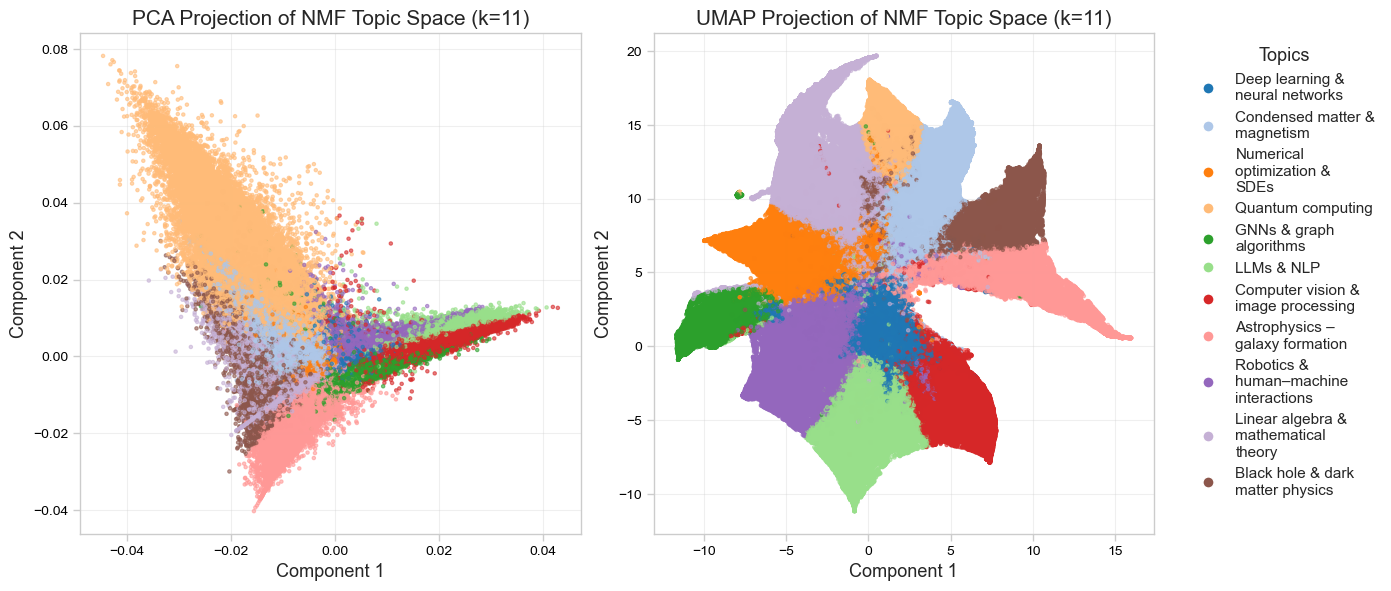

In [42]:
# Plot Projections
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ["PCA Projection", "UMAP Projection"]

for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
    ax.scatter(
        emb[:, 0], emb[:, 1],
        c=topic_colors,
        s=6,
        alpha=0.6
    )
    ax.set_title(f"{title} of NMF Topic Space (k={k})", fontsize=15)
    ax.set_xlabel("Component 1", fontsize=13)
    ax.set_ylabel("Component 2", fontsize=13)
    ax.grid(alpha=0.3)
    for spine in ax.spines.values():
        spine.set_color("#cccccc")
    ax.tick_params(axis='both', which='both', labelsize=10)

# Shared Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o', color='w',
        markerfacecolor=color_map[t],
        markersize=8,
        label="\n".join(textwrap.wrap(topic_labels.get(t, f"Topic {t}"), width=18))
    )
    for t in topic_ids
    ]
axes[1].legend(
    handles=legend_elements,
    title="Topics",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=11,
    title_fontsize=13,
    ncol=1,
    frameon=False
)

# Axis ticks
for ax in axes:
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        left=True,
        color=spine_color,
        labelcolor='black'
    )

plt.tight_layout()
plt.savefig(f'Visualizations/nmf_pca_vs_umap_k{k}.png', dpi=300, bbox_inches='tight')
plt.show()